In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models # add models to the list
from torchvision.utils import make_grid
from torchvision import models
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix
%matplotlib inline

# ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
train_transform = transforms.Compose([
        transforms.RandomRotation(10),      # rotate +/- 10 degrees
        transforms.RandomHorizontalFlip(),  # reverse 50% of images
        transforms.Resize(224),             # resize shortest side to 224 pixels
        transforms.CenterCrop(224),         # crop longest side to 224 pixels at center
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

test_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

In [9]:
root = r"C:\Users\HP\Documents\DeepLearning\train_test"

train_data = datasets.ImageFolder(os.path.join(root, 'Train'), transform=train_transform)
test_data = datasets.ImageFolder(os.path.join(root, 'Test'), transform=test_transform)

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=2, shuffle=False)

class_names = train_data.classes

print(class_names)
print(f'Training images available: {len(train_data)}')
print(f'Testing images available:  {len(test_data)}')

['Cat', 'Dog', 'Pandas']
Training images available: 204
Testing images available:  34


In [10]:
Resnetmodel = models.resnet18(pretrained=True)
num_ftrs = Resnetmodel.fc.in_features

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


In [11]:

# Freeze feature parameters
for param in Resnetmodel.parameters():
    param.requires_grad = False


In [12]:
# Modify the classifier

torch.manual_seed(42)

Resnetmodel.fc = nn.Sequential(
    nn.Linear(Resnetmodel.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 3),
    nn.LogSoftmax(dim=1)
)

In [13]:
for param in Resnetmodel.parameters():
    print(param.numel())

9408
64
64
36864
64
64
36864
64
64
36864
64
64
36864
64
64
73728
128
128
147456
128
128
8192
128
128
147456
128
128
147456
128
128
294912
256
256
589824
256
256
32768
256
256
589824
256
256
589824
256
256
1179648
512
512
2359296
512
512
131072
512
512
2359296
512
512
2359296
512
512
262144
512
1536
3


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(Resnetmodel.fc.parameters(), lr=0.001)

In [15]:
# Set time tracking
import time
start_time = time.time()

epochs = 3

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):

    trn_corr = 0
    tst_corr = 0

    # TRAINING
    for b, (X_train, y_train) in enumerate(train_loader):

        # Apply ResNet model
        y_pred = Resnetmodel(X_train)

        loss = criterion(y_pred, y_train)

        # Predictions
        predicted = torch.max(y_pred, 1)[1]

        # Count correct predictions
        trn_corr += (predicted == y_train).sum()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print progress every 10 batches
        if b % 10 == 0:
            acc = trn_corr.item()*100 / ((b+1)*train_loader.batch_size)
            print(f'Epoch: {i+1} Batch: {b+1} Loss: {loss.item():.4f} Accuracy: {acc:.2f}%')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # TESTING
    with torch.no_grad():

        for b, (X_test, y_test) in enumerate(test_loader):

            y_val = Resnetmodel(X_test)

            predicted = torch.max(y_val, 1)[1]

            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)

    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f"\nTraining Time: {time.time() - start_time:.2f} seconds")

Epoch: 1 Batch: 1 Loss: 1.3033 Accuracy: 25.00%
Epoch: 1 Batch: 11 Loss: 0.8654 Accuracy: 52.27%
Epoch: 1 Batch: 21 Loss: 0.3694 Accuracy: 61.90%
Epoch: 1 Batch: 31 Loss: 0.5535 Accuracy: 70.97%
Epoch: 1 Batch: 41 Loss: 0.0306 Accuracy: 76.22%
Epoch: 1 Batch: 51 Loss: 0.0473 Accuracy: 78.43%
Epoch: 2 Batch: 1 Loss: 0.0356 Accuracy: 100.00%
Epoch: 2 Batch: 11 Loss: 0.1706 Accuracy: 93.18%
Epoch: 2 Batch: 21 Loss: 0.0239 Accuracy: 89.29%
Epoch: 2 Batch: 31 Loss: 0.0825 Accuracy: 91.94%
Epoch: 2 Batch: 41 Loss: 0.0066 Accuracy: 91.46%
Epoch: 2 Batch: 51 Loss: 0.0362 Accuracy: 92.65%
Epoch: 3 Batch: 1 Loss: 0.0138 Accuracy: 100.00%
Epoch: 3 Batch: 11 Loss: 0.0616 Accuracy: 90.91%
Epoch: 3 Batch: 21 Loss: 0.3758 Accuracy: 86.90%
Epoch: 3 Batch: 31 Loss: 0.4259 Accuracy: 87.10%
Epoch: 3 Batch: 41 Loss: 0.1547 Accuracy: 89.63%
Epoch: 3 Batch: 51 Loss: 0.0280 Accuracy: 90.20%

Training Time: 39.80 seconds


In [16]:
print(test_correct)
print(f'Test accuracy: {test_correct[-1].item()*100/len(test_data):.3f}%')

[tensor(15), tensor(16), tensor(16)]
Test accuracy: 47.059%


In [17]:
# Inverse normalize the images
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

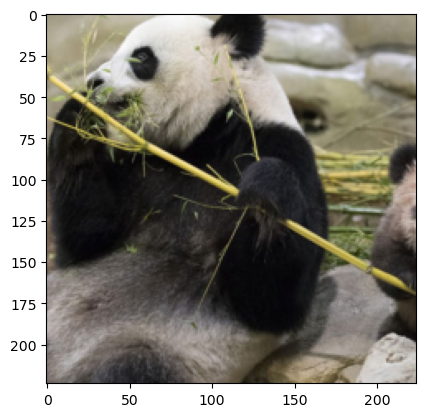

In [18]:
image_index = 25
im = inv_normalize(test_data[image_index][0])
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));
plt.show()



In [19]:
# ResNet Model Prediction

Resnetmodel.eval()

with torch.no_grad():
    new_pred = Resnetmodel(test_data[image_index][0].view(1,3,224,224)).argmax()

class_names[new_pred.item()]

'Pandas'

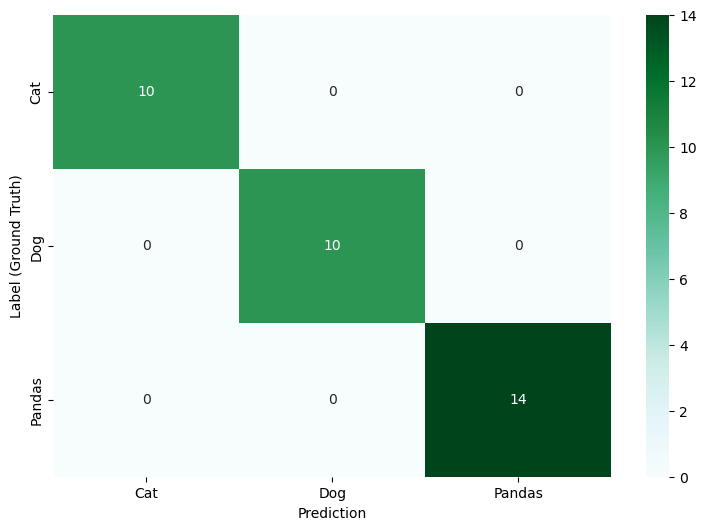

In [20]:

# Create loader for entire test set
test_load_all = DataLoader(test_data, batch_size=20, shuffle=False)

Resnetmodel.eval()

with torch.no_grad():

    correct = 0
    all_preds = []
    all_labels = []

    for X_test, y_test in test_load_all:

        y_val = Resnetmodel(X_test)

        predicted = torch.max(y_val,1)[1]

        correct += (predicted == y_test).sum()

        all_preds.extend(predicted.numpy())
        all_labels.extend(y_test.numpy())

# Confusion Matrix
arr = confusion_matrix(all_labels, all_preds)

df_cm = pd.DataFrame(arr, class_names, class_names)

plt.figure(figsize=(9,6))
sn.heatmap(df_cm, annot=True, fmt="d", cmap="BuGn")

plt.xlabel("Prediction")
plt.ylabel("Label (Ground Truth)")
plt.show()